In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import os


In [14]:
# Load data
prices_data = pd.read_csv('../../data/raw/features/prices_2019_15102025.csv')
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-10-06.csv")
hh_info = pd.read_csv("../../data/processed/hh_info.csv")
adm2_average = pd.read_csv("../../data/processed/adm2_average.csv")

In [37]:
# load the data
def load_data(filepath):
    try: 
        return pd.read_csv(filepath)
    except Exception as e: 
        print(f"Error loading {filepath}: {e}")
        return None

# pre process data 

def preprocess_prices(df):
    """Filter and pivot price data for analysis."""
    filtered = df.copy()

    # Combine all rice types
    filtered['Commodity'] = filtered['Commodity'].apply(
        lambda x: 'Rice' if 'rice' in x.lower() else x
    )

    # Extract month as numeric (1–12)
    filtered['month'] = pd.to_datetime(filtered['Price Date'], format="%d/%m/%Y").dt.strftime("%B")

    # Group by Admin 2, Commodity, and month, then take median price
    grouped = (
        filtered.groupby(["Admin 2", "Commodity", "month"])
        .agg({'Price': 'median'})
        .reset_index()
    )

    # Pivot to wide format
    pivoted = grouped.pivot(index=['Admin 2', 'month'], columns='Commodity', values='Price')
    pivoted = pivoted.reset_index()

    return pivoted


In [44]:

df= preprocess_prices(prices_data)
df


Commodity,Admin 2,month,Fuel (diesel),Fuel (petrol-gasoline),Rice,Sugar,Wheat flour
0,Ampara,April,95.0,117.0,73.57750,112.13,87.3203
1,Ampara,August,117.0,95.0,76.90000,108.20,87.2000
2,Ampara,December,95.0,117.0,80.62240,111.00,87.4200
3,Ampara,February,NaN,NaN,73.59260,NaN,86.3188
4,Ampara,January,NaN,NaN,78.97665,NaN,86.6738
...,...,...,...,...,...,...,...
294,Vavuniya,March,NaN,NaN,82.46000,NaN,86.9018
295,Vavuniya,May,95.0,117.0,85.17950,NaN,84.9704
296,Vavuniya,November,95.0,117.0,97.00000,112.50,89.3300
297,Vavuniya,October,95.0,117.0,93.80000,110.00,89.6700


# prices over months

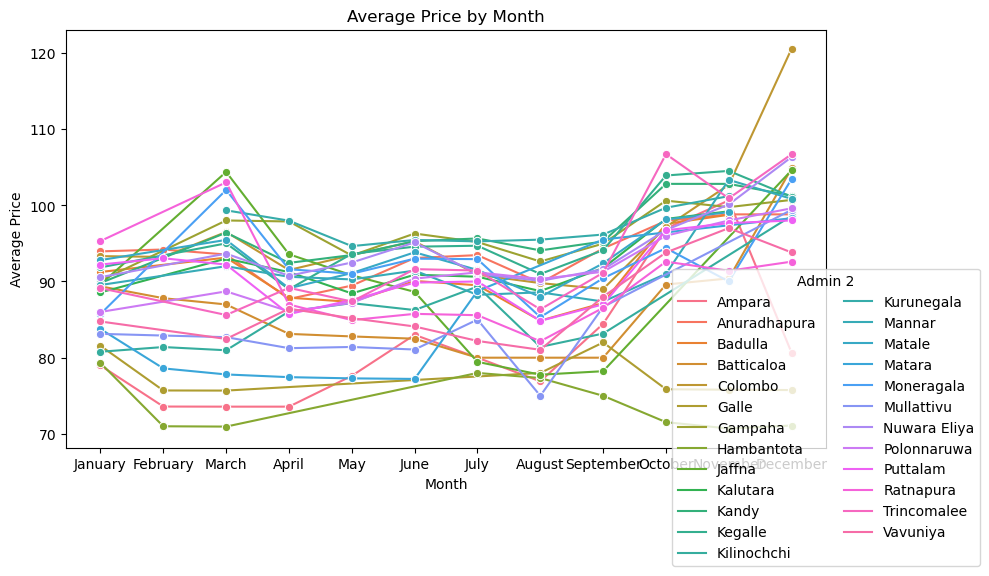

In [62]:


# Group by month and commodity, calculate average price

# # Sort months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

df_long = df.melt(
    id_vars=['Admin 2', 'month'],
    var_name='commodity',
    value_name='price'
)

df_long = df_long[df_long['commodity'] == "Rice"]
df_long
# # # Plot

# Plot using FacetGrid
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_long, x='month', y='price', hue='Admin 2', marker='o')
plt.title('Average Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.legend(title='Admin 2',loc='lower center', bbox_to_anchor=(1, -0.3), ncol=2)
plt.tight_layout()
plt.show()




Functions to create plots for EDA

In [22]:

def plot_heatmap(df, title="Prices of Commodities per Admin 2", cmap="Blues"):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(df, cmap=cmap, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Commodity")
    ax.set_ylabel("Admin 2")
    fig.tight_layout()
    return fig




def plot_histograms(df, commodities=None, country_label='LKA'):
    figs = []
    if commodities is None:
        commodities = df.columns

    for commodity in commodities:
        if commodity in df.columns:
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.histplot(data=df, x=commodity, bins=20, kde=True, ax=ax)
            ax.set_xlabel(f"{commodity} price ({country_label})")
            ax.set_ylabel("Count")
            ax.set_title(f"Distribution of {commodity} Prices")
            fig.tight_layout()
            figs.append((commodity, fig))
        else:
            print(f"Commodity '{commodity}' not found in data.")
    return figs





def plot_data(df, commodities=None, country_label='LKA'):
    if df is not None:
        pivot_data = preprocess_prices(df)
        heatmap_fig = plot_heatmap(pivot_data, title=f"Prices of Commodities per Admin 2 ({country_label})")
        histogram_figs = plot_histograms(pivot_data, commodities=commodities, country_label=country_label)
        return {
            "heatmap": heatmap_fig,
            "histograms": histogram_figs,
            "analysis": pivot_data
        }
    else:
        print("No data provided.")
        return None





Apply the analysis in one function

In [25]:


def produce_plots(filepaths):
    results = {}
    for path in filepaths:
        try:
            df = load_data(path)
            output = plot_data(df)
            filename = os.path.basename(path)
            folder_name = os.path.splitext(filename)[0]
            os.makedirs("../../outputs/plots/prices/"+folder_name, exist_ok=True)

            # Save heatmap
            heatmap_path = os.path.join("../../outputs/plots/prices/",folder_name, "heatmap.png")
            output["heatmap"].savefig(heatmap_path)
            plt.close(output["heatmap"])

            # Save histograms
            for commodity, fig in output["histograms"]:
                hist_path = os.path.join("../../outputs/plots/prices/",folder_name, f"{commodity}_histogram.png")
                fig.savefig(hist_path)
                plt.close(fig)

            results[filename] = output["analysis"]
            print(f"\nAnalysis for {filename}:\n{output['analysis']}")
            print(f"Plots saved in folder: {folder_name}")

        except Exception as e:
            print(f"Error processing {path}: {e}")
            results[os.path.basename(path)] = None
    return results



print the results

In [26]:

files = ['../../data/raw/features/prices_2024_03112025.csv', '../../data/raw/features/prices_2019_15102025.csv']  # Replace with your actual file paths
results = produce_plots(files)

for filename, result in results.items():
    # print(f"\nAnalysis for {filename}:\n")
    print(result)


<positron-console-cell-26>:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



Analysis for prices_2024_03112025.csv:
Commodity       Bananas      Beans  Beans (mung)    Cabbage    Carrots  Chili (red, dry raw)  ...    Pumpkin       Rice  Snake gourd   Sugar   Tomatoes  Wheat flour
Admin 2                                                                                       ...                                                                   
Ampara        166.68600  522.10650     845.06570  366.58975  438.99995             698.89975  ...  186.24620  232.08800    321.53595     NaN  380.73535          NaN
Anuradhapura  169.59100  549.41670     868.10890  333.03860  462.71210             754.06790  ...  191.99440  232.71130    296.06010     NaN  366.72340          NaN
Badulla       175.71630  484.55000     919.47925  277.43220  392.84845             738.23800  ...  204.96295  231.14540    315.84310     NaN  311.12615          NaN
Batticaloa    176.40620  576.97340     892.85730  401.57580  376.95690             744.52370  ...  180.50000  232.59320    291.20990   

## Prices vs intake for 2019 data

In [ ]:

def clean_prices_data(prices_data):
    prices_data = preprocess_prices(prices_data)
    prices_data.columns = [str(col) for col in prices_data.columns]
    return prices_data.reset_index()

def merge_district_codes(prices_data, adm2_average):
    districts = [
        {"adm2": 81, "Admin 2": "Badulla"}, {"adm2": 11, "Admin 2": "Colombo"},
        {"adm2": 12, "Admin 2": "Gampaha"}, {"adm2": 41, "Admin 2": "Jaffna"},
        {"adm2": 13, "Admin 2": "Kalutara"}, {"adm2": 21, "Admin 2": "Kandy"},
        {"adm2": 92, "Admin 2": "Kegalle"}, {"adm2": 61, "Admin 2": "Kurunegala"},
        {"adm2": 43, "Admin 2": "Mannar"}, {"adm2": 22, "Admin 2": "Matale"},
        {"adm2": 82, "Admin 2": "Moneragala"}, {"adm2": 23, "Admin 2": "Nuwara Eliya"},
        {"adm2": 72, "Admin 2": "Polonnaruwa"}, {"adm2": 91, "Admin 2": "Ratnapura"},
        {"adm2": 53, "Admin 2": "Trincomalee"}, {"adm2": 44, "Admin 2": "Vavuniya"}
    ]
    df_districts = pd.DataFrame(districts)
    prices_data=prices_data.merge(df_districts, on='Admin 2')

    adm2_inad = (
        adm2_average[['adm2', 'energy_kcal_q50'] + [col for col in adm2_average.columns if col.endswith('_inad')]]
        .merge(prices_data, on='adm2', how='left')
    )


    return adm2_inad
  
def add_province_names(df):
    province_map = {
        1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
        6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
    }
    df['province'] = (df['adm2'] // 10).round().map(province_map)
    return df

def define_variable_groups(df):
    mn_col_names = list(df.columns[2:8])
    price_col_names = list(df.columns[11:15])
    return mn_col_names, price_col_names

def plot_scatter_with_regression(df, x_var, y_var, output_dir="outputs/plots/prices"):
    print(f"Plotting {y_var} vs {x_var}")
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x_var, y=y_var, hue='province', s=50)
    sns.regplot(data=df, x=x_var, y=y_var, scatter=False, color='black')

    # Clean data
    X = sm.add_constant(df[x_var])
    y = df[y_var]
    data = pd.concat([X, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    X_clean = data.iloc[:, :-1]
    y_clean = data.iloc[:, -1]

    # Fit model
    model = sm.OLS(y_clean, X_clean).fit()
    r_squared = model.rsquared
    intercept, slope = model.params
    pearson_r = slope / abs(slope) * r_squared**0.5

    # Annotate
    eq_label = f"$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_squared:.2f}$\n$Pearson = {pearson_r:.2f}$"
    plt.text(0.05, 0.95, eq_label, transform=plt.gca().transAxes,
             verticalalignment='top', horizontalalignment='left', fontsize=10)

    plt.title(f"Scatterplot of {y_var} vs {x_var}")
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/{y_var}_{x_var}.png")
    plt.close()

In [ ]:
def analyze_relationships(adm2_average, prices_data):
    prices_data = clean_prices_data(prices_data)
    prices_data = merge_district_codes(prices_data, adm2_average)
    adm2_inad = add_province_names(prices_data)
    mn_col_names, price_col_names = define_variable_groups(adm2_inad)

    for y_var in mn_col_names:
        for x_var in price_col_names:
            plot_scatter_with_regression(adm2_inad, x_var, y_var)
